# Risk ratio de dry spells largos en 4 regiones de Chile

Pregunta: ¿cambió la probabilidad de **dry spells** largos entre **1980–2000** y **2001–2021**?

Referencia metodológica: Martinez-Villalobos & Neelin (2018), [10.1029/2018GL078465](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2018GL078465).

> **Analogía con la Fig. 5 del paper:** allí el eje X es el **umbral de tamaño** de acumulaciones de precipitación (eventos húmedos) y el eje Y es el **risk ratio** entre dos periodos, con **banda de incertidumbre por bootstrap**. Aquí aplicamos la misma lógica a **dry spells**: eje X = duración mínima del evento (días), eje Y = P₂/P₁, con bootstrap **por año** (como en `Pregunta2.ipynb` y `preg2(fecha17abril).ipynb`).

## Definiciones
- **Día seco:** precipitación diaria `pr < 1 mm/día` (CR2MET v2.5).
- **Dry spell:** racha consecutiva de días secos.
- **Filtro estacional:** solo rachas cuyo **inicio** cae entre **marzo y noviembre** (consistente con `preg2(fecha17abril).ipynb`).
- **Evento:** dry spell con duración ≥ umbral (p. ej. 20 días).
- **Probabilidad del evento:** fracción de rachas con duración ≥ umbral; cada racha se asigna al **año de inicio**.
- **Risk ratio (RR):** P₂/P₁, donde P₁ y P₂ son las probabilidades en 1980–2000 y 2001–2021.
- **Pool regional:** se agrupan todas las rachas de los píxeles CR2MET dentro de cada región administrativa (Natural Earth).
- **Ventanas comparables:** P₁ y P₂ tienen **21 años** cada uno (1980–2000 y 2001–2021), sin solapamiento.

## Regiones analizadas
Coquimbo, O'Higgins, La Araucanía y Los Lagos.



In [ ]:
import warnings
import unicodedata
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.prepared import prep
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = ':'

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2021-12-31'
DRY_THRESHOLD = 0.1›
EVENT_THRESHOLD = 20
BOOTSTRAP_ITER = 1000
RANDOM_SEED = 42
PERIOD_1 = (1980, 2000)
PERIOD_2 = (2001, 2021)
THRESHOLD_SWEEP = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
SEASON_MONTH_MIN = 3
SEASON_MONTH_MAX = 11
RR_PLOT_YMAX = 4.0  # Tope visual; umbrales altos en zonas humedas pueden disparar el RR

REGION_SPECS = {
    'Coquimbo': {'query': 'Coquimbo', 'color': 'firebrick'},
    "O'Higgins": {'query': 'higgins', 'color': 'darkorange'},
    'La Araucanía': {'query': 'araucan', 'color': 'forestgreen'},
    'Los Lagos': {'query': 'los lagos', 'color': 'steelblue'},
}

# =====================================================================
# FUNCIONES AUXILIARES
# =====================================================================
def normalize_text(text):
    text = unicodedata.normalize('NFKD', str(text).lower())
    return ''.join(ch for ch in text if not unicodedata.combining(ch))


def get_region_record(query, chile_records):
    query_norm = normalize_text(query)
    for record in chile_records:
        name_norm = normalize_text(record.attributes.get('name', ''))
        if query_norm in name_norm:
            return record
    raise ValueError(f'No se encontro region chilena para: {query}')


def build_region_mask(lat2d, lon2d, polygon):
    prepg = prep(polygon)
    return np.fromiter(
        (
            prepg.contains(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            or polygon.touches(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            for j in range(lat2d.shape[0])
            for i in range(lat2d.shape[1])
        ),
        dtype=bool,
        count=lat2d.size,
    ).reshape(lat2d.shape)


def extract_dry_spells(pr_values, times, dry_threshold, season_month_min=SEASON_MONTH_MIN, season_month_max=SEASON_MONTH_MAX):
    """Extrae dry spells; conserva solo rachas que comienzan entre marzo y noviembre."""
    records = []
    nlat, nlon = pr_values.shape[1], pr_values.shape[2]
    times = pd.to_datetime(times)

    for j in range(nlat):
        for i in range(nlon):
            vals = pr_values[:, j, i]
            if np.all(np.isnan(vals)):
                continue

            is_dry = np.isfinite(vals) & (vals < dry_threshold)
            x = np.concatenate(([0], is_dry.astype(np.int8), [0]))
            dx = np.diff(x)
            starts = np.where(dx == 1)[0]
            ends = np.where(dx == -1)[0]

            for s, e in zip(starts, ends):
                duration = int(e - s)
                if duration <= 0:
                    continue
                start_month = int(times[s].month)
                if start_month < season_month_min or start_month > season_month_max:
                    continue
                records.append({
                    'start_year': int(times[s].year),
                    'start_month': start_month,
                    'duration': duration,
                })

    return pd.DataFrame(records)


def event_probability(spell_df, start_year, end_year, min_duration):
    subset = spell_df[
        (spell_df['start_year'] >= start_year) & (spell_df['start_year'] <= end_year)
    ].copy()
    total_spells = int(len(subset))
    event_spells = int((subset['duration'] >= min_duration).sum())
    probability = np.nan if total_spells == 0 else event_spells / total_spells
    return subset, probability, event_spells, total_spells


def risk_ratio(prob_period_2, prob_period_1):
    if prob_period_1 == 0 or not np.isfinite(prob_period_1):
        return np.nan
    return prob_period_2 / prob_period_1


def bootstrap_rr_by_year(spell_df, years_1, years_2, min_duration, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    grouped = {
        year: spell_df.loc[spell_df['start_year'] == year, 'duration'].to_numpy()
        for year in sorted(spell_df['start_year'].unique())
    }
    years_1 = np.array(list(years_1))
    years_2 = np.array(list(years_2))
    rr_values = []

    for _ in range(n_iter):
        draw_1 = rng.choice(years_1, size=len(years_1), replace=True)
        draw_2 = rng.choice(years_2, size=len(years_2), replace=True)

        sample_1 = np.concatenate([grouped[year] for year in draw_1 if grouped[year].size > 0])
        sample_2 = np.concatenate([grouped[year] for year in draw_2 if grouped[year].size > 0])

        if sample_1.size == 0 or sample_2.size == 0:
            continue

        p1 = np.mean(sample_1 >= min_duration)
        p2 = np.mean(sample_2 >= min_duration)
        if p1 > 0:
            rr_values.append(p2 / p1)

    return np.array(rr_values)


def bootstrap_rr_curve(spell_df, years_1, years_2, thresholds, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    """RR observado e IC95 bootstrap para cada umbral de duracion (estilo Fig. 5)."""
    rows = []
    for thr in thresholds:
        _, p1, _, _ = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], thr)
        _, p2, _, _ = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], thr)
        rr_boot = bootstrap_rr_by_year(spell_df, years_1, years_2, thr, n_iter=n_iter, seed=seed)
        if rr_boot.size == 0:
            ci_low = ci_high = ci_med = np.nan
        else:
            ci_low, ci_high = np.percentile(rr_boot, [2.5, 97.5])
            ci_med = np.median(rr_boot)
        rr_obs = risk_ratio(p2, p1)
        rows.append({
            'Umbral (dias)': thr,
            'RR': rr_obs,
            'RR bootstrap mediano': ci_med,
            'IC95 inferior': ci_low,
            'IC95 superior': ci_high,
            'Significativo aumento': np.isfinite(ci_low) and ci_low > 1.0,
            'Significativo disminucion': np.isfinite(ci_high) and ci_high < 1.0,
            'P1 (%)': p1 * 100 if np.isfinite(p1) else np.nan,
            'P2 (%)': p2 * 100 if np.isfinite(p2) else np.nan,
        })
    return pd.DataFrame(rows)


def load_region_spell_data(ds, record):
    geom = record.geometry
    region_name = record.attributes.get('name', 'region')
    minx, miny, maxx, maxy = geom.bounds

    lat_slice = slice(maxy, miny) if float(ds.lat[0]) > float(ds.lat[-1]) else slice(miny, maxy)
    lon_slice = slice(minx, maxx) if float(ds.lon[0]) < float(ds.lon[-1]) else slice(maxx, minx)

    pr_region = ds['pr'].sel(lat=lat_slice, lon=lon_slice)
    lat2d, lon2d = np.meshgrid(pr_region['lat'].values, pr_region['lon'].values, indexing='ij')
    mask = build_region_mask(lat2d, lon2d, geom)
    mask_da = xr.DataArray(mask, coords={'lat': pr_region.lat, 'lon': pr_region.lon}, dims=('lat', 'lon'))

    pr_masked = pr_region.where(mask_da).compute()
    spell_df = extract_dry_spells(pr_masked.values, pr_masked['time'].values, DRY_THRESHOLD)

    return {
        'name': region_name,
        'geom': geom,
        'bounds': (minx, miny, maxx, maxy),
        'mask': mask,
        'mask_da': mask_da,
        'pr_region': pr_masked,
        'spell_df': spell_df,
        'pixels': int(mask.sum()),
    }


print('1/4: Cargando CR2MET y registros administrativos de Chile...')
shape_path = shpreader.natural_earth(
    resolution='10m', category='cultural', name='admin_1_states_provinces'
)
reader = shpreader.Reader(shape_path)
CHILE_REGIONS = [r for r in reader.records() if r.attributes.get('admin') == 'Chile']

ds = xr.open_mfdataset(
    './pr/CR2MET_pr_v2.5_day_*.nc',
    combine='by_coords',
    engine='netcdf4',
    chunks={'time': 365},
)
ds = ds.sel(time=slice(START_DATE, END_DATE))

print(f'Periodo: {START_DATE} a {END_DATE}')
print(f'Dia seco: pr < {DRY_THRESHOLD} mm/dia')
print(f'Filtro estacional: inicio Mar-Nov ({SEASON_MONTH_MIN}-{SEASON_MONTH_MAX})')
print(f'Periodos RR: {PERIOD_1[0]}-{PERIOD_1[1]} vs {PERIOD_2[0]}-{PERIOD_2[1]}')


print(
    f'Anos por periodo: P1={PERIOD_1[1] - PERIOD_1[0] + 1} ({PERIOD_1[0]}-{PERIOD_1[1]}), '
    f'P2={PERIOD_2[1] - PERIOD_2[0] + 1} ({PERIOD_2[0]}-{PERIOD_2[1]})'
)


1/4: Cargando CR2MET y registros administrativos de Chile...
Periodo: 1980-01-01 a 2021-12-31
Dia seco: pr < 0.1 mm/dia
Filtro estacional: inicio Mar-Nov (3-11)
Periodos RR: 1980-2000 vs 2001-2021
Anos por periodo: P1=21 (1980-2000), P2=21 (2001-2021)


2/4: Extrayendo dry spells por region...
  Coquimbo         | Coquimbo               | pixeles: 1407 | spells: 947,976
  O'Higgins        | Libertador General Bernardo O'Higgins | pixeles:  651 | spells: 735,125
  La Araucanía     | La Araucanía           | pixeles: 1401 | spells: 2,230,860
  Los Lagos        | Los Lagos              | pixeles: 2065 | spells: 2,959,858


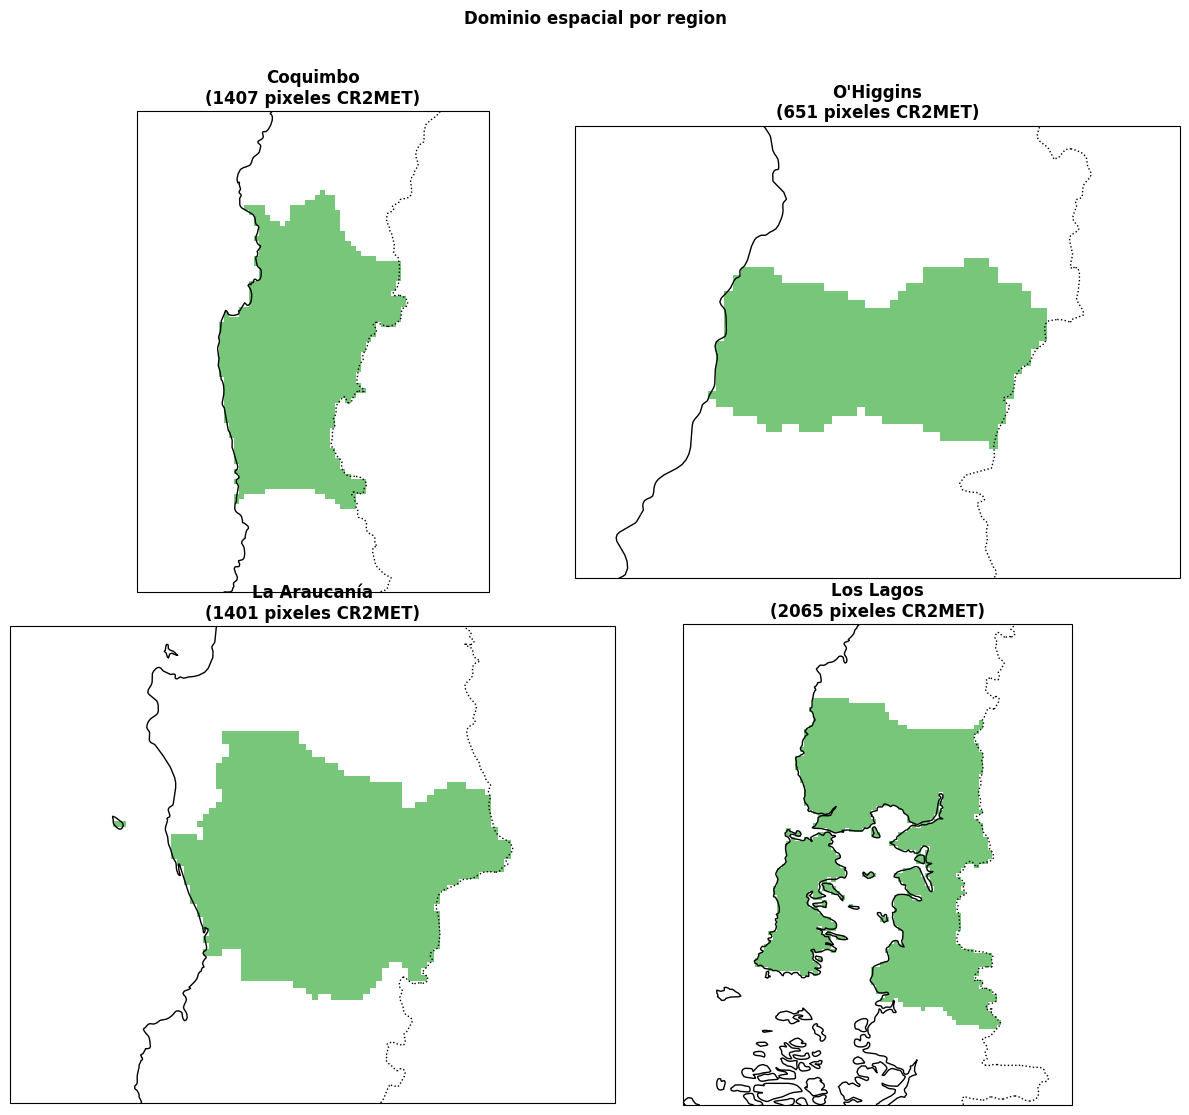

In [2]:
# =====================================================================
# EXTRACCION DE DRY SPELLS EN LAS 4 REGIONES
# =====================================================================
print('2/4: Extrayendo dry spells por region...')

REGION_DATA = {}
for label, spec in REGION_SPECS.items():
    record = get_region_record(spec['query'], CHILE_REGIONS)
    data = load_region_spell_data(ds, record)
    REGION_DATA[label] = data
    print(
        f"  {label:16s} | {data['name']:22s} | "
        f"pixeles: {data['pixels']:4d} | spells: {len(data['spell_df']):,}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 11), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.ravel()

for ax, (label, spec) in zip(axes, REGION_SPECS.items()):
    data = REGION_DATA[label]
    minx, miny, maxx, maxy = data['bounds']
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([minx - 0.8, maxx + 0.8, miny - 0.8, maxy + 0.8])

    plot_da = data['mask_da'].astype(float).where(data['mask_da'])
    plot_da.plot.pcolormesh(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='YlGn', add_colorbar=False,
    )
    ax.set_title(f"{label}\n({data['pixels']} pixeles CR2MET)", fontweight='bold')

fig.suptitle('Dominio espacial por region', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [3]:
# =====================================================================
# RISK RATIO A 20 DIAS + BOOTSTRAP (4 REGIONES)
# =====================================================================
print(f'3/4: Risk ratio para dry spells >= {EVENT_THRESHOLD} dias...')

years_1 = range(PERIOD_1[0], PERIOD_1[1] + 1)
years_2 = range(PERIOD_2[0], PERIOD_2[1] + 1)

summary_rows = []
rr_rows = []

for label in REGION_SPECS:
    spell_df = REGION_DATA[label]['spell_df']

    _, prob_1, hits_1, total_1 = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], EVENT_THRESHOLD)
    _, prob_2, hits_2, total_2 = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], EVENT_THRESHOLD)
    rr_obs = risk_ratio(prob_2, prob_1)

    rr_boot = bootstrap_rr_by_year(spell_df, years_1, years_2, EVENT_THRESHOLD)
    if rr_boot.size > 0:
        ci_low, ci_med, ci_high = np.percentile(rr_boot, [2.5, 50, 97.5])
    else:
        ci_low = ci_med = ci_high = np.nan

    summary_rows.extend([
        {
            'Region': label,
            'Periodo': f'{PERIOD_1[0]}-{PERIOD_1[1]}',
            'Dry spells totales': total_1,
            f'Spells >= {EVENT_THRESHOLD} d': hits_1,
            'Probabilidad (%)': prob_1 * 100 if np.isfinite(prob_1) else np.nan,
        },
        {
            'Region': label,
            'Periodo': f'{PERIOD_2[0]}-{PERIOD_2[1]}',
            'Dry spells totales': total_2,
            f'Spells >= {EVENT_THRESHOLD} d': hits_2,
            'Probabilidad (%)': prob_2 * 100 if np.isfinite(prob_2) else np.nan,
        },
    ])

    rr_rows.append({
        'Region': label,
        'Pixeles': REGION_DATA[label]['pixels'],
        'RR observado': rr_obs,
        'RR bootstrap mediano': ci_med,
        'IC95 inferior': ci_low,
        'IC95 superior': ci_high,
        'Cruza RR=1': (ci_low <= 1 <= ci_high) if np.all(np.isfinite([ci_low, ci_high])) else np.nan,
    })

summary_table = pd.DataFrame(summary_rows)
rr_table = pd.DataFrame(rr_rows)

display(summary_table.round(3))
display(rr_table.round(3))


3/4: Risk ratio para dry spells >= 20 dias...


,Region,Periodo,Dry spells totales,Spells >= 20 d,Probabilidad (%)
0,Coquimbo,1980-2000,503766,106977,21.235
1,Coquimbo,2001-2021,444210,110408,24.855
2,O'Higgins,1980-2000,371249,30519,8.221
3,O'Higgins,2001-2021,363876,31644,8.696
4,La Araucanía,1980-2000,1093858,6757,0.618
5,La Araucanía,2001-2021,1137002,6661,0.586
6,Los Lagos,1980-2000,1463620,658,0.045
7,Los Lagos,2001-2021,1496238,688,0.046


,Region,Pixeles,RR observado,RR bootstrap mediano,IC95 inferior,IC95 superior,Cruza RR=1
0,Coquimbo,1407,1.170,1.171,0.985,1.409,True
1,O'Higgins,651,1.058,1.059,0.874,1.283,True
2,La Araucanía,1401,0.948,0.985,0.399,3.013,True
3,Los Lagos,2065,1.023,1.165,0.203,109.081,True


4/4: Risk ratio vs umbral con bootstrap (4 regiones)...


,Umbral (dias),RR,RR bootstrap mediano,IC95 inferior,IC95 superior,Significativo aumento,Significativo disminucion,P1 (%),P2 (%),Region
0,20,1.170,1.171,0.985,1.409,False,False,21.235,24.855,Coquimbo
1,20,1.058,1.059,0.874,1.283,False,False,8.221,8.696,O'Higgins
2,20,0.948,0.985,0.399,3.013,False,False,0.618,0.586,La Araucanía
3,20,1.023,1.165,0.203,109.081,False,False,0.045,0.046,Los Lagos


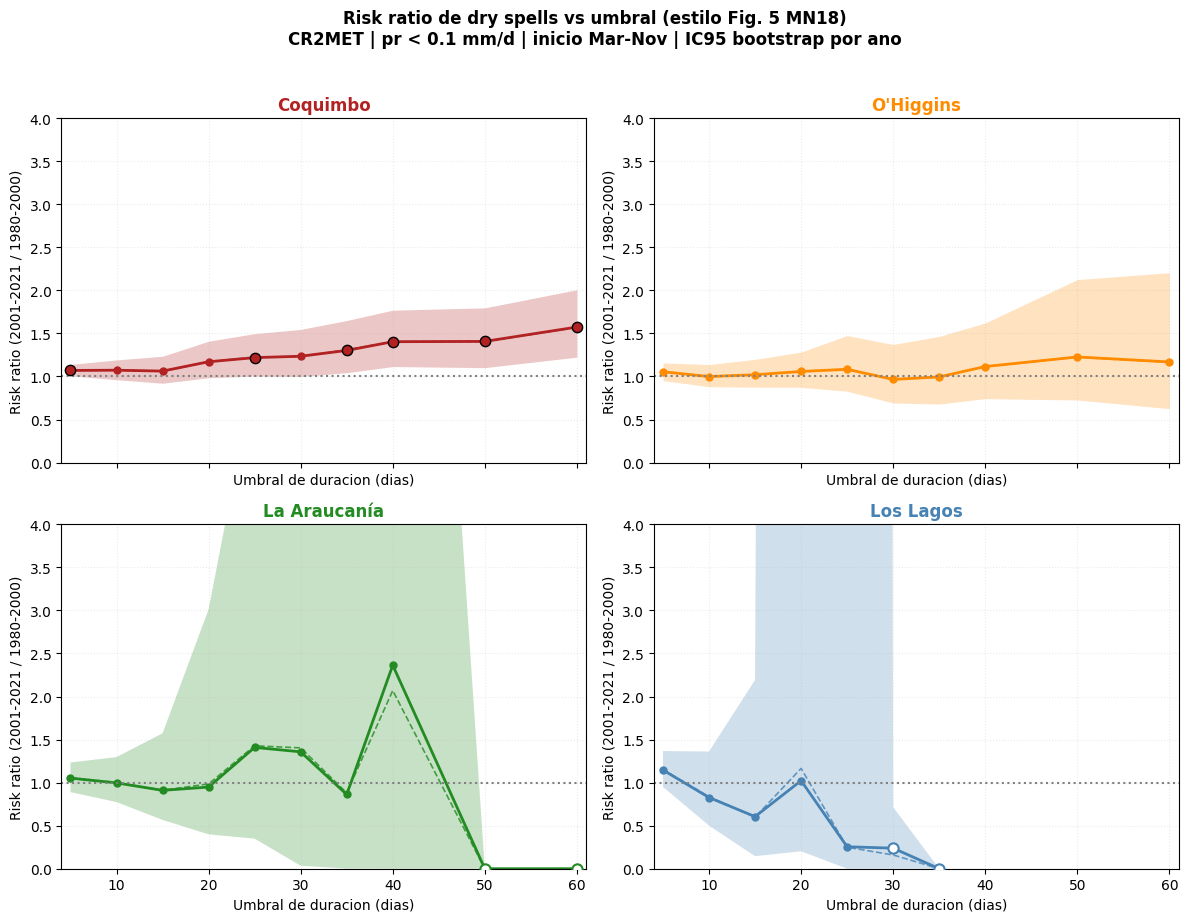

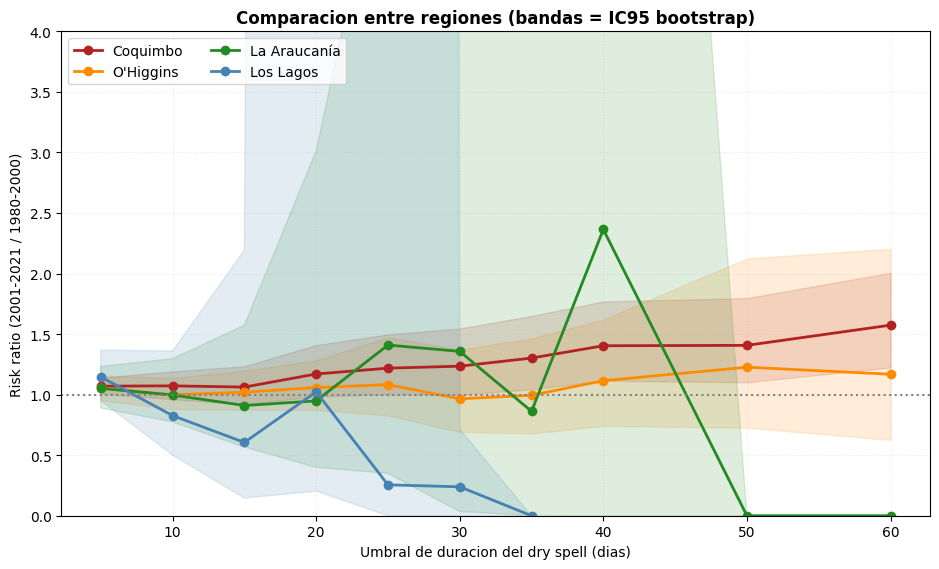

,Region,RR @ 20d,IC95 inf,IC95 sup,Significancia
0,Coquimbo,1.170,0.985,1.409,no
1,O'Higgins,1.058,0.874,1.283,no
2,La Araucanía,0.948,0.399,3.013,no
3,Los Lagos,1.023,0.203,109.081,no


Lectura:
  - Curvas cerca de RR=1: cambio debil (no confundir con "cero").
  - RR alto en Los Lagos a umbrales grandes: P1 muy pequena -> ratio inestable; eje Y acotado a 4.0
  - Significancia: IC95 por encima de 1 (aumento) o por debajo de 1 (disminucion).


In [4]:
# =====================================================================
# FIGURA ESTILO FIG. 5 (MN18): RR VS UMBRAL + IC95 BOOTSTRAP
# =====================================================================
print('4/4: Risk ratio vs umbral con bootstrap (4 regiones)...')

years_1 = range(PERIOD_1[0], PERIOD_1[1] + 1)
years_2 = range(PERIOD_2[0], PERIOD_2[1] + 1)

threshold_by_region = {}
for label in REGION_SPECS:
    spell_df = REGION_DATA[label]['spell_df']
    threshold_by_region[label] = bootstrap_rr_curve(
        spell_df, years_1, years_2, THRESHOLD_SWEEP, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED,
    )

table_20 = pd.concat(
    [threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD]
     .assign(Region=label)
     for label in REGION_SPECS],
    ignore_index=True,
)
display(table_20.round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
axes = axes.ravel()

for ax, (label, spec) in zip(axes, REGION_SPECS.items()):
    tdf = threshold_by_region[label]
    color = spec['color']
    x = tdf['Umbral (dias)'].to_numpy()
    rr = tdf['RR'].to_numpy()
    lo = tdf['IC95 inferior'].to_numpy()
    hi = tdf['IC95 superior'].to_numpy()

    valid = np.isfinite(rr) & np.isfinite(lo) & np.isfinite(hi)
    if valid.any():
        ax.fill_between(x[valid], lo[valid], hi[valid], color=color, alpha=0.25, linewidth=0)
        ax.plot(x[valid], rr[valid], color=color, marker='o', linewidth=2, markersize=5, label='RR')
        ax.plot(x[valid], tdf.loc[valid, 'RR bootstrap mediano'], color=color, linestyle='--', linewidth=1.2, alpha=0.8)

        sig_up = tdf.loc[valid, 'Significativo aumento'].to_numpy()
        sig_down = tdf.loc[valid, 'Significativo disminucion'].to_numpy()
        if sig_up.any():
            ax.scatter(x[valid][sig_up], rr[valid][sig_up], s=55, facecolors=color, edgecolors='k', zorder=5)
        if sig_down.any():
            ax.scatter(x[valid][sig_down], rr[valid][sig_down], s=55, facecolors='white', edgecolors=color, linewidth=1.5, zorder=5)

    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(label, fontweight='bold', color=color)
    ax.set_xlabel('Umbral de duracion (dias)')
    ax.set_ylabel('Risk ratio (2001-2021 / 1980-2000)')
    ax.set_xlim(THRESHOLD_SWEEP[0] - 1, THRESHOLD_SWEEP[-1] + 1)
    ax.set_ylim(0, RR_PLOT_YMAX)

fig.suptitle(
    'Risk ratio de dry spells vs umbral (estilo Fig. 5 MN18)\n'
    f'CR2MET | pr < {DRY_THRESHOLD} mm/d | inicio Mar-Nov | IC95 bootstrap por ano',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
for label, spec in REGION_SPECS.items():
    tdf = threshold_by_region[label]
    valid = tdf['RR'].notna() & tdf['IC95 inferior'].notna() & tdf['IC95 superior'].notna()
    x = tdf.loc[valid, 'Umbral (dias)']
    ax.fill_between(x, tdf.loc[valid, 'IC95 inferior'], tdf.loc[valid, 'IC95 superior'], color=spec['color'], alpha=0.15)
    ax.plot(x, tdf.loc[valid, 'RR'], color=spec['color'], marker='o', linewidth=2, label=label)

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('Umbral de duracion del dry spell (dias)')
ax.set_ylabel('Risk ratio (2001-2021 / 1980-2000)')
ax.set_title('Comparacion entre regiones (bandas = IC95 bootstrap)', fontweight='bold')
ax.set_ylim(0, RR_PLOT_YMAX)
ax.legend(loc='upper left', frameon=True, ncol=2)
plt.tight_layout()
plt.show()

sig_table = pd.DataFrame([
    {
        'Region': label,
        'RR @ 20d': threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'RR'].iloc[0],
        'IC95 inf': threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'IC95 inferior'].iloc[0],
        'IC95 sup': threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'IC95 superior'].iloc[0],
        'Significancia': (
            'aumento' if threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'Significativo aumento'].iloc[0]
            else ('disminucion' if threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD, 'Significativo disminucion'].iloc[0] else 'no')
        ),
    }
    for label in REGION_SPECS
])
display(sig_table.round(3))

print('Lectura:')
print('  - Curvas cerca de RR=1: cambio debil (no confundir con "cero").')
print('  - RR alto en Los Lagos a umbrales grandes: P1 muy pequena -> ratio inestable; eje Y acotado a', RR_PLOT_YMAX)
print('  - Significancia: IC95 por encima de 1 (aumento) o por debajo de 1 (disminucion).')

